# Cafe data EDA to find out the realtion between
* Quantity and Price Per Unit impact on total spend
* Total Spent by Transaction Date
* Total Spent against Location
* Total Spent against Payment Method

# Library we will need

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings
import statsmodels.api as sm
warnings.filterwarnings('ignore')

## Load data

In [2]:
df = pd.read_csv('clean_cafe_data.csv')
df.head(10)

,Transaction ID,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,4,1.0,8.9,Credit Card,In-store,2023-07-19
3,TXN_7034554,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,5,4.0,20.0,Credit Card,UNKNOWN,2023-03-31
6,TXN_4433211,3,3.0,9.0,UNKNOWN,Takeaway,2023-10-06
7,TXN_6699534,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,5,3.0,15.0,UNKNOWN,Takeaway,2023-07-28
9,TXN_2064365,5,4.0,20.0,UNKNOWN,In-store,2023-12-31


In [3]:
df.shape

(10000, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Quantity          10000 non-null  int64  
 2   Price Per Unit    10000 non-null  float64
 3   Total Spent       10000 non-null  float64
 4   Payment Method    10000 non-null  object 
 5   Location          10000 non-null  object 
 6   Transaction Date  10000 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 547.0+ KB


## Extracted new column from the transaction date, called day of week

In [5]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Day_of_Week'] = df['Transaction Date'].dt.day_name()

In [6]:
df.head(10)

,Transaction ID,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day_of_Week
0,TXN_1961373,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday
1,TXN_4977031,4,3.0,12.0,Cash,In-store,2023-05-16,Tuesday
2,TXN_4271903,4,1.0,8.9,Credit Card,In-store,2023-07-19,Wednesday
3,TXN_7034554,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,Thursday
4,TXN_3160411,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday
5,TXN_2602893,5,4.0,20.0,Credit Card,UNKNOWN,2023-03-31,Friday
6,TXN_4433211,3,3.0,9.0,UNKNOWN,Takeaway,2023-10-06,Friday
7,TXN_6699534,4,4.0,16.0,Cash,UNKNOWN,2023-10-28,Saturday
8,TXN_4717867,5,3.0,15.0,UNKNOWN,Takeaway,2023-07-28,Friday
9,TXN_2064365,5,4.0,20.0,UNKNOWN,In-store,2023-12-31,Sunday


In [7]:
df = df[['Quantity' , 'Price Per Unit' ,	'Total Spent' , 'Payment Method' , 'Location' , 'Day_of_Week']]

In [8]:
df.isnull().sum()

Quantity          0
Price Per Unit    0
Total Spent       0
Payment Method    0
Location          0
Day_of_Week       0
dtype: int64

## Lets check quantity and price per unit impact on Total spent

In [9]:
df['Day_of_Week'].value_counts(normalize = True)

Day_of_Week
Monday       0.1453
Friday       0.1448
Sunday       0.1437
Thursday     0.1436
Saturday     0.1432
Wednesday    0.1415
Tuesday      0.1379
Name: proportion, dtype: float64

In [10]:
df['Payment Method'].value_counts(normalize = True)

Payment Method
UNKNOWN           0.3178
Digital Wallet    0.2291
Credit Card       0.2273
Cash              0.2258
Name: proportion, dtype: float64

In [11]:
df['Location'].value_counts(normalize = True)

Location
UNKNOWN     0.3961
Takeaway    0.3022
In-store    0.3017
Name: proportion, dtype: float64

In [12]:
df.describe()

,Quantity,Price Per Unit,Total Spent
count,10000.000000,10000.00000,10000.000000
mean,3.027100,2.94732,8.923130
std,1.384614,1.24396,5.857115
min,1.000000,1.00000,1.000000
25%,2.000000,2.00000,4.000000
50%,3.000000,3.00000,8.000000
75%,4.000000,4.00000,12.000000
max,5.000000,5.00000,25.000000


## used some plots to identify the outliers

{'whiskers': [<matplotlib.lines.Line2D at 0x2d74d9dc050>,
 'caps': [<matplotlib.lines.Line2D at 0x2d74d9dc2d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2d74d707d90>],
 'medians': [<matplotlib.lines.Line2D at 0x2d74d9dc550>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d74d9dc690>],
 'means': []}

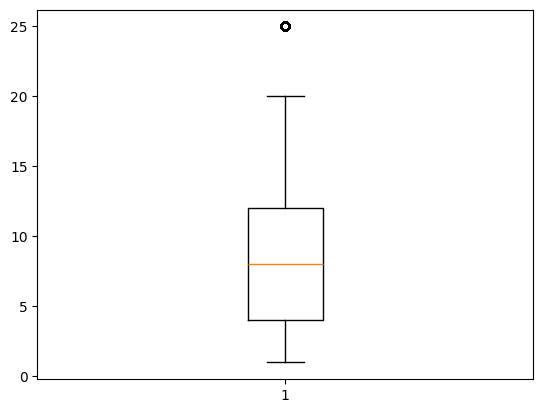

In [13]:
plt.boxplot(df['Total Spent'])

In [14]:
outlier = df[df['Total Spent'] == 25]
outlier

,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Day_of_Week
10,5,5.0,25.0,Cash,Takeaway,Tuesday
51,5,5.0,25.0,UNKNOWN,Takeaway,Sunday
52,5,5.0,25.0,Digital Wallet,UNKNOWN,Wednesday
96,5,5.0,25.0,Cash,In-store,Saturday
100,5,5.0,25.0,Cash,Takeaway,Monday
...,...,...,...,...,...,...
9791,5,5.0,25.0,Digital Wallet,In-store,Wednesday
9805,5,5.0,25.0,UNKNOWN,UNKNOWN,Tuesday
9879,5,5.0,25.0,Digital Wallet,In-store,Thursday
9908,5,5.0,25.0,Credit Card,UNKNOWN,Thursday


## As the data is skewed and it is not normalized.
* IQR WILL BE BEST FIT HERE

In [15]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# now it only have data with no outlier
df = df[(df['Total Spent'] >= lower) & (df['Total Spent'] <= upper)]
df

,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Day_of_Week
0,2,2.0,4.0,Credit Card,Takeaway,Friday
1,4,3.0,12.0,Cash,In-store,Tuesday
2,4,1.0,8.9,Credit Card,In-store,Wednesday
3,2,5.0,10.0,UNKNOWN,UNKNOWN,Thursday
4,2,2.0,4.0,Digital Wallet,In-store,Sunday
...,...,...,...,...,...,...
9995,2,2.0,4.0,UNKNOWN,UNKNOWN,Wednesday
9996,3,2.9,3.0,Digital Wallet,UNKNOWN,Friday
9997,4,2.0,8.0,Digital Wallet,UNKNOWN,Thursday
9998,3,2.9,3.0,Digital Wallet,UNKNOWN,Saturday


### Exactly 259 row are removed from here which were outlier in Total Spent.

In [16]:
259 /10000 *100

2.59

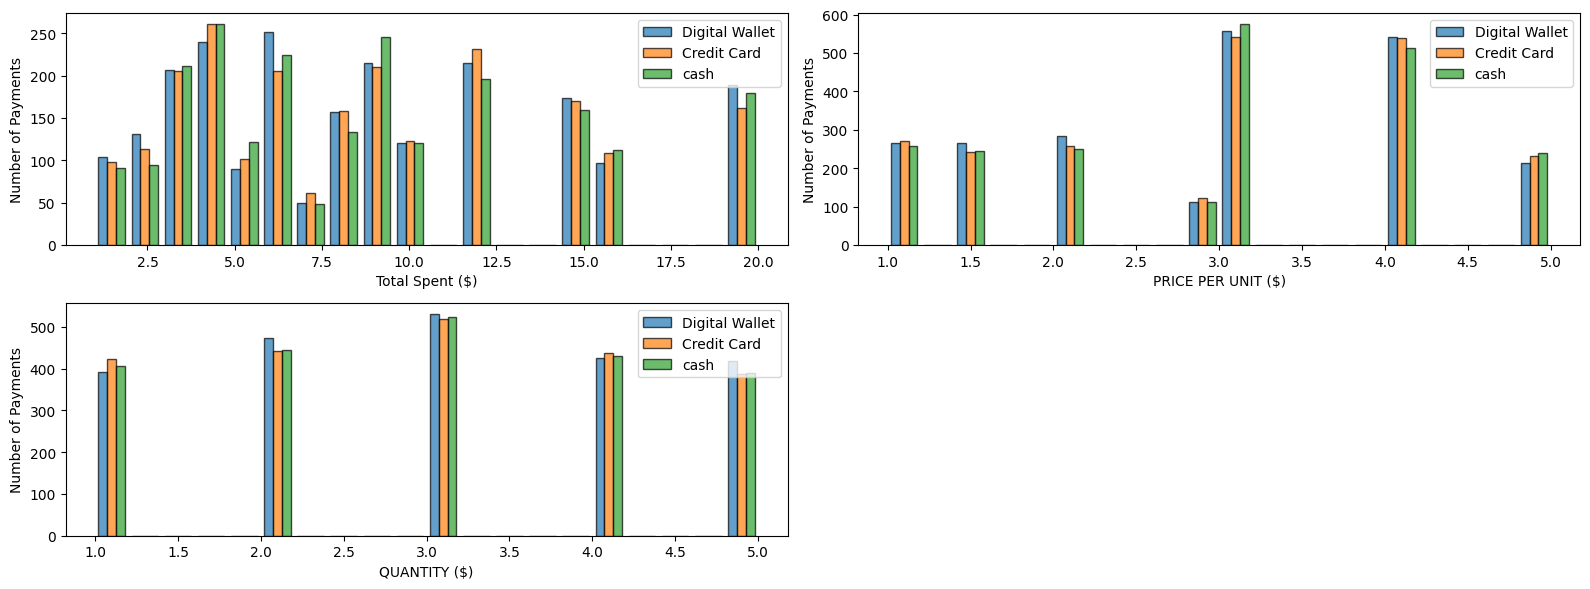

In [17]:
fig, ax = plt.subplots(2,2, figsize=(16,6))

digital = df[df['Payment Method'] == 'Digital Wallet']['Total Spent']
card = df[df['Payment Method'] == 'Credit Card']['Total Spent']
cash = df[df['Payment Method'] == 'Cash']['Total Spent']

digitalprice = df[df['Payment Method'] == 'Digital Wallet']['Price Per Unit']
cardprice = df[df['Payment Method'] == 'Credit Card']['Price Per Unit']
cashprice = df[df['Payment Method'] == 'Cash']['Price Per Unit']

digitalQ = df[df['Payment Method'] == 'Digital Wallet']['Quantity']
cardQ = df[df['Payment Method'] == 'Credit Card']['Quantity']
cashQ = df[df['Payment Method'] == 'Cash']['Quantity']


ax[0,0].hist([digital, card, cash], bins=20, stacked=False, alpha=0.7, 
        label=['Digital Wallet', 'Credit Card', 'cash'], edgecolor='black')

ax[0,0].set_xlabel('Total Spent ($)')
ax[0,0].set_ylabel('Number of Payments')
ax[0,0].legend()

ax[0,1].hist([digitalprice, cardprice, cashprice], bins=20, stacked=False, alpha=0.7, 
        label=['Digital Wallet', 'Credit Card', 'cash'], edgecolor='black')

ax[0,1].set_xlabel('PRICE PER UNIT ($)')
ax[0,1].set_ylabel('Number of Payments')
ax[0,1].legend()

ax[1,0].hist([digitalQ, cardQ, cashQ], bins=20, stacked=False, alpha=0.7, 
        label=['Digital Wallet', 'Credit Card', 'cash'], edgecolor='black')

ax[1,0].set_xlabel('QUANTITY ($)')
ax[1,0].set_ylabel('Number of Payments')
ax[1,0].legend()

ax[1,1].remove()

plt.tight_layout()
plt.show()

## bar chart with respect to day,
*this is done because 30% day is unknown in payment method*

In [18]:
unknown = df[df['Payment Method'] == 'UNKNOWN']
unknown.value_counts().sum() / len(df) * 100

np.float64(31.772918591520376)

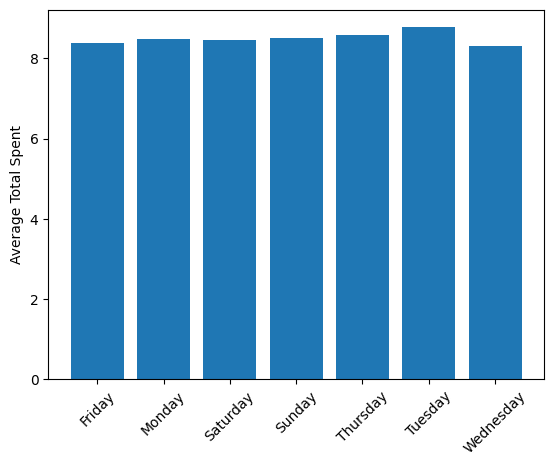

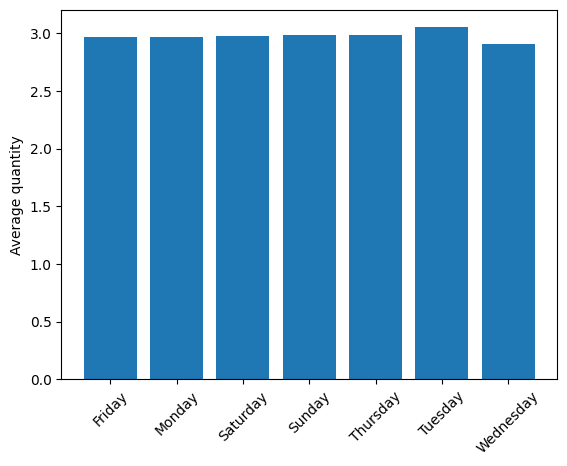

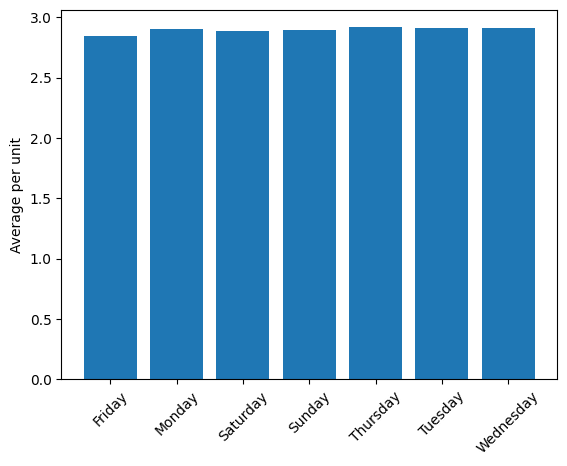

In [19]:
dayspent = df.groupby('Day_of_Week')['Total Spent'].mean()

plt.bar(dayspent.index, dayspent.values)
plt.xticks(rotation=45)
plt.ylabel('Average Total Spent')
plt.show()

qualityspent = df.groupby('Day_of_Week')['Quantity'].mean()

plt.bar(qualityspent.index, qualityspent.values)
plt.xticks(rotation=45)
plt.ylabel('Average quantity')
plt.show()

perunitspent = df.groupby('Day_of_Week')['Price Per Unit'].mean()

plt.bar(perunitspent.index, perunitspent.values)
plt.xticks(rotation=45)
plt.ylabel('Average per unit')
plt.show()

### Customer purchasing behavior remains relatively *consistent* throughout the week, with *no single day showing a significant increase* in *spending, quantity purchased, or product prices* in above graph.

## AS there is not significance in payment method, with respect to Quantity , Price per unit or the Total spent
* They almost have similar probability.

In [20]:
df.groupby('Payment Method')['Total Spent'].mean()

Payment Method
Cash              8.612836
Credit Card       8.558986
Digital Wallet    8.584196
UNKNOWN           8.303231
Name: Total Spent, dtype: float64

In [21]:
df.groupby('Payment Method')['Total Spent'].median()

Payment Method
Cash              8.0
Credit Card       8.0
Digital Wallet    8.0
UNKNOWN           8.0
Name: Total Spent, dtype: float64

In [22]:
df.groupby('Payment Method')['Total Spent'].sum()

Payment Method
Cash              18922.4
Credit Card       18906.8
Digital Wallet    19228.6
UNKNOWN           25698.5
Name: Total Spent, dtype: float64

## Aggrigation function applied on Quantity, Price Per Unit and Total Spent 

In [23]:
df.groupby('Payment Method').agg({'Quantity':['mean','std'],'Price Per Unit':['mean','std'], 'Total Spent':['mean','std']})

Quantity           Price Per Unit           Total Spent  \
                    mean       std           mean       std        mean   
Payment Method                                                            
Cash            2.979062  1.360220       2.930906  1.226768    8.612836   
Credit Card     2.966048  1.366070       2.923359  1.230418    8.558986   
Digital Wallet  3.001339  1.360286       2.886071  1.216153    8.584196   
UNKNOWN         2.966721  1.376172       2.859483  1.200030    8.303231   

                          
                     std  
Payment Method            
Cash            5.343908  
Credit Card     5.291455  
Digital Wallet  5.406159  
UNKNOWN         5.215364

## From table it is clear that there is *not one significant payent method, all are marginally same*
* people prefer **cash and digital wallet**
* **credit card** is *less prefered way to pay*

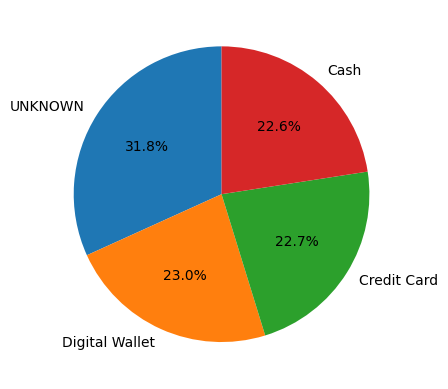

In [24]:
prefered_method = df['Payment Method'].value_counts()

plt.pie(prefered_method.values, labels= prefered_method.index, startangle = 90, autopct = '%1.1f%%')
plt.show()

In [25]:
df['Payment Method'].value_counts(normalize = True) * 100

Payment Method
UNKNOWN           31.772919
Digital Wallet    22.995586
Credit Card       22.677343
Cash              22.554153
Name: proportion, dtype: float64

In [26]:
df['Total Spent'].unique()

array([ 4. , 12. ,  8.9, 10. , 20. ,  9. , 16. , 15. ,  8. ,  5. ,  3. ,
        6. ,  2. ,  1. ,  7.5,  4.5,  1.5])

# horizontal bar chart 
* showing relation between Total and payment method
* it will tell what payment method is contributing how much

In [27]:
df

,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Day_of_Week
0,2,2.0,4.0,Credit Card,Takeaway,Friday
1,4,3.0,12.0,Cash,In-store,Tuesday
2,4,1.0,8.9,Credit Card,In-store,Wednesday
3,2,5.0,10.0,UNKNOWN,UNKNOWN,Thursday
4,2,2.0,4.0,Digital Wallet,In-store,Sunday
...,...,...,...,...,...,...
9995,2,2.0,4.0,UNKNOWN,UNKNOWN,Wednesday
9996,3,2.9,3.0,Digital Wallet,UNKNOWN,Friday
9997,4,2.0,8.0,Digital Wallet,UNKNOWN,Thursday
9998,3,2.9,3.0,Digital Wallet,UNKNOWN,Saturday


In [28]:
Totalspent = df.groupby(['Payment Method', 'Total Spent'])[['Total Spent']].count()
Totalspent.rename(columns = {'Total Spent':'spentcount'}, inplace = True)
Totalspent.reset_index(inplace = True)

Totalspent['spentpercent'] = (Totalspent['spentcount'] /Totalspent['spentcount'].sum())* 100
Totalspent.head()

,Payment Method,Total Spent,spentcount,spentpercent
0,Cash,1.0,45,0.461965
1,Cash,1.5,46,0.472231
2,Cash,2.0,94,0.964993
3,Cash,3.0,211,2.166102
4,Cash,4.0,203,2.083975


## Above table show spent count and spenpercent
- **Total spent have listed each dollor**
- **spentcount have listed how many people pay that respective dollor**
- **spentcount have listed then percent of each respective dollor**

In [29]:
# pivot will do best here, 
newdf = Totalspent.pivot(
    index='Payment Method',
    columns='Total Spent',
    values='spentpercent'
)
pivot_df = newdf.T

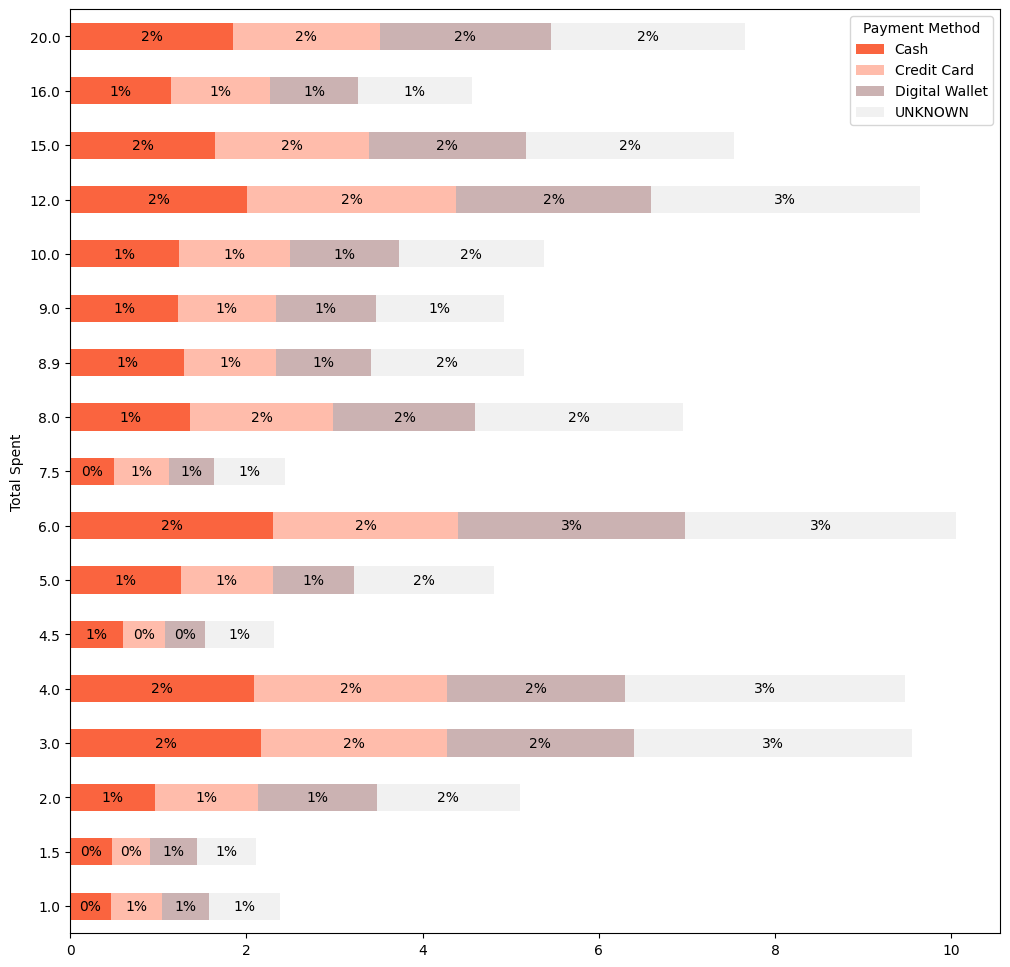

In [30]:
fig, ax = plt.subplots(figsize = (12, 12))

pivot_df.plot(ax = ax, kind = 'barh', stacked = True, color = ['#FA643F', '#FFBCAB', '#CBB2B2', '#F1F1F1', '#FD9F9F'])

for i in ax.patches:
    width = i.get_width()
    height = i.get_height()
    x, y = i.get_xy()
    ax.text(
            x + width / 2,
            y + height/ 2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center'
    )
plt.savefig('payment_method_chart.jpg', dpi=300, bbox_inches='tight')

## This also prove that payment method does not show any significance, as all of them are used in very similar proportion 

### Lets run hypothesis, to prove the fact
- There is no significant relationship between Payment Method and Price.Customers do not choose payment methods differently based on price.
- There is a significant relationship between Payment Method and Price.Customers choose payment methods differently based on price.

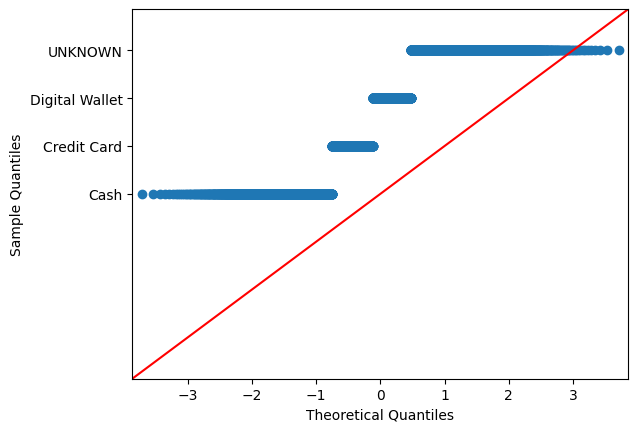

In [31]:
# THIS QQ PLOT show that total spent definately not a 
sm.qqplot(df['Payment Method'], line='45')
plt.show()

In [32]:
cash = df[df['Payment Method'] == 'Cash']['Total Spent'].dropna()
card = df[df['Payment Method'] == 'Credit Card']['Total Spent'].dropna()
digital = df[df['Payment Method'] == 'Digital Wallet']['Total Spent'].dropna()
unknown = df[df['Payment Method'] == 'UNKNOWN']['Total Spent'].dropna()

In [33]:
h_stat, p_value = st.kruskal(cash, card, digital, unknown)

In [34]:
p_value

np.float64(0.13245069770389847)

## Null hypothesis is that there is no significance in total spent and payment method

In [35]:
if p_value < 0.05:
    print('Reject the null hypothesis: Significant relationship exists.')
else:
    print('Do not reject the null hypothesis: No significant relationship found.')

Do not reject the null hypothesis: No significant relationship found.


# Regression analysis

In [41]:
# one variable effect on other

# Independend 
spending = Totalspent['Total Spent']

# Dependend
paytype = Totalspent['Payment Method']
